## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D) 

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들) 
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

train: 73257장, test: 26032장
raw shape: (73257, 3, 32, 32)


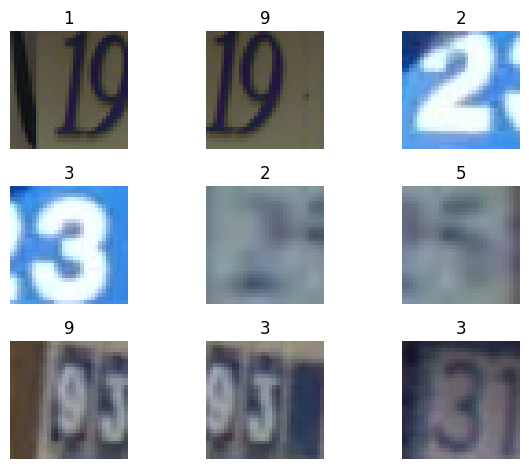

In [ ]:
# 데이터셋 정의 -> SVHN (Street View House Numbers)
# 32x32 RGB 3채널 / 10 클래스(숫자 0~9) / train 73,257장, test 26,032장
# CIFAR-10과 해상도·채널·클래스 수가 같아 아래 CNN 구조를 그대로 쓸 수 있음

# SVHN 채널별 mean / std
SVHN_MEAN = (0.4377, 0.4438, 0.4728)
SVHN_STD = (0.1980, 0.2010, 0.1970)

# 주의: 숫자 이미지이므로 RandomHorizontalFlip은 쓰면 안 됨 (2 <-> 5 처럼 라벨이 깨짐)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(SVHN_MEAN, SVHN_STD),
])

# test에는 augmentation 없이 ToTensor + Normalize만 (train과 같은 정규화를 써야 분포가 맞음)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(SVHN_MEAN, SVHN_STD),
])

# torchvision 데이터셋은 __getitem__에서 PIL 이미지를 넘겨주므로 ToPILImage()가 필요 없음
train_data = datasets.SVHN(
    root='./data/',
    split='train',
    download=True,
    transform=train_transform,
)

test_data = datasets.SVHN(
    root='./data/',
    split='test',
    download=True,
    transform=test_transform,
)

# SVHN의 raw data는 (N, 3, 32, 32) uint8, 라벨은 .targets가 아니라 .labels
print(f"train: {len(train_data)}장, test: {len(test_data)}장")
print(f"raw shape: {train_data.data.shape}")

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i].transpose(1, 2, 0))  # (C, H, W) -> (H, W, C)
    plt.title(str(train_data.labels[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# sanity check: 모델에 들어가는 최종 텐서 모양 / 값 범위 확인
# (torchvision 데이터셋에 transform을 직접 넘겼으므로 커스텀 Dataset 클래스는 필요 없음)
img, label = train_data[0]
print(f"train sample: {img.shape}, dtype={img.dtype}, label={label}")

img, label = test_data[0]
print(f"test  sample: {img.shape}, dtype={img.dtype}, label={label}")

# train/test 모두 (3, 32, 32) float32 여야 함. test가 uint8이면 transform이 안 걸린 것
assert img.shape == (3, 32, 32) and img.dtype == torch.float32

train sample: torch.Size([3, 32, 32]), dtype=torch.float32, label=1
test  sample: torch.Size([3, 32, 32]), dtype=torch.float32, label=5


## Modeling

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()        
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''
    
    def forward(self, x): 
        x = self.conv1(x)
        x = self.relu(self.bn1(x))
        x = self.conv2(x)
        x = self.relu(self.bn2(x))
        x = self.pool(x)
        return x

        # return self.model(x)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()
        
        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)
        
        # classification을 위한 FC 정의
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로
        
        x = self.fc1(self.dropout(x))
        x = self.relu(x)
        x = self.fc2(self.dropout(x))
        x = self.relu(x)
        x = self.fc3(self.dropout(x))
        
        return x

In [ ]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: mps


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  

In [ ]:
# Learning rate
lr = 1e-3

# Optimizer, Loss
optim = Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Train loop
model.train()  # dropout을 켜는 학습 모드 (평가 후 다시 학습할 때 반드시 필요)
best_val_loss = float('inf')
min_delta = 1e-4
patience = 5
best_epoch = -1
epochs_no_improve = 0
early_stopped = False

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}


for epoch in range(100):
    model.train()
    running, n = 0.0, 0
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Iniitlaization
        
        preds = model(data.to(device)) # prediction
        
        # Loss Function
        loss = criterion(preds, label.to(device))
        prev_loss = loss.item()

        loss.backward()
        optim.step()

        running += loss.item() * data.size(0)
        n += data.size(0)
    train_loss = running / n

    model.eval()
    val_running, val_corr, n = 0.0, 0, 0
    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.to(device)
            out = model(data)
            val_running += criterion(out, label).item() * data.size(0)
            val_corr += out.argmax(1).eq(label).sum().item()
            n += data.size(0)
    val_loss = val_running / n
    val_acc = val_corr / n

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"epoch {epoch+1:3d} | train {train_loss:.4f} | val {val_loss:.4f} | val_acc {val_acc:.4f}")

    if val_loss < best_val_loss - min_delta:
        best_val_loss, best_epoch = val_loss, epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), "SVHN_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stopped = True
            print(f"Early stopping at epoch {epoch + 1} | best = epoch {best_epoch + 1} (val_loss {best_val_loss:.4f})")
            break
            


# 모델 저장
if early_stopped:
    torch.save(model.state_dict(), "SVHN.pth")

print(f"학습 종료. best epoch {best_epoch+1}, val_loss {best_val_loss:.4f}")


  0%|          | 0/1145 [00:00<?, ?it/s]

100%|██████████| 1145/1145 [00:37<00:00, 30.51it/s]


epoch   1 | train 1.4297 | val 0.4557 | val_acc 0.8650


100%|██████████| 1145/1145 [00:30<00:00, 37.93it/s]


epoch   2 | train 0.4682 | val 0.3426 | val_acc 0.9017


...

epoch  27 | train 0.1149 | val 0.1802 | val_acc 0.9585


100%|██████████| 1145/1145 [00:29<00:00, 39.21it/s]


epoch  28 | train 0.1167 | val 0.1795 | val_acc 0.9602


100%|██████████| 1145/1145 [00:29<00:00, 38.68it/s]


epoch  29 | train 0.1103 | val 0.1863 | val_acc 0.9551
Early stopping at epoch 29 | best = epoch 24 (val_loss 0.1706)
학습 종료. best epoch 24, val_loss 0.1706


In [ ]:
model.load_state_dict(torch.load("SVHN_best.pth", map_location=device))

model.eval()  # dropout을 끄는 평가 모드. torch.no_grad()는 gradient만 끌 뿐 dropout은 그대로 켜져 있음

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 407/407 [00:03<00:00, 120.87it/s]

Accuracy:0.9584357713583282


In [ ]:
class BasicBlocknoBN(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlocknoBN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()        
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''
    
    def forward(self, x): 
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

class CNNwithNoDropOut(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNNwithNoDropOut, self).__init__()
        
        # CNN 블럭 정의
        self.block1 = BasicBlocknoBN(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlocknoBN(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlocknoBN(in_channels=128, out_channels=256, hidden_dim=128)
        
        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        
        return x

In [ ]:
default_model = CNNwithNoDropOut(10)
default_model.to(device)
# Learning rate
lr = 1e-3

# Optimizer, Loss
optim = Adam(default_model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Train loop
default_model.train()  # 학습 모드 (이 모델엔 dropout / BN이 없어 eval과 동작은 같지만 습관적으로 명시)
best_val_loss = float('inf')
min_delta = 1e-4
patience = 5
best_epoch = -1
epochs_no_improve = 0
early_stopped = False

history2 = {'train_loss': [], 'val_loss': [], 'val_acc': []}


for epoch in range(100):
    default_model.train()
    running, n = 0.0, 0
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Iniitlaization
        
        preds = default_model(data.to(device)) # prediction
        
        # Loss Function
        loss = criterion(preds, label.to(device))
        prev_loss = loss.item()

        loss.backward()
        optim.step()

        running += loss.item() * data.size(0)
        n += data.size(0)
    train_loss = running / n

    default_model.eval()
    val_running, val_corr, n = 0.0, 0, 0
    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.to(device)
            out = default_model(data)
            val_running += criterion(out, label).item() * data.size(0)
            val_corr += out.argmax(1).eq(label).sum().item()
            n += data.size(0)
    val_loss = val_running / n
    val_acc = val_corr / n

    # 이 셀은 history2에 기록 (history는 위쪽 model 학습 결과이므로 덮어쓰면 안 됨)
    history2['train_loss'].append(train_loss)
    history2['val_loss'].append(val_loss)
    history2['val_acc'].append(val_acc)
    print(f"epoch {epoch+1:3d} | train {train_loss:.4f} | val {val_loss:.4f} | val_acc {val_acc:.4f}")

    if val_loss < best_val_loss - min_delta:
        best_val_loss, best_epoch = val_loss, epoch
        epochs_no_improve = 0
        torch.save(default_model.state_dict(), "SVHN_default_best.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            early_stopped = True
            print(f"Early stopping at epoch {epoch + 1} | best = epoch {best_epoch + 1} (val_loss {best_val_loss:.4f})")
            break
            


# 모델 저장
if early_stopped:
    torch.save(default_model.state_dict(), "SVHN_default.pth")

print(f"학습 종료. best epoch {best_epoch+1}, val_loss {best_val_loss:.4f}")


In [ ]:
default_model.load_state_dict(torch.load("SVHN_default_best.pth", map_location=device))

default_model.eval()  # dropout을 끄는 평가 모드. torch.no_grad()는 gradient만 끌 뿐 dropout은 그대로 켜져 있음

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = default_model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 407/407 [00:02<00:00, 158.83it/s]

Accuracy:0.9437231100184389


- 전반적으로 DropOut, BatchNormalization을 적용한 모델이 epoch당 학습 시간은 오래걸렸지만 더 빠르게 학습이 되었고 최종 정확도도 더 높게 나타났다.